In [2]:
import torch 
import numpy as np

In [3]:
!nvidia-smi

Mon Mar 16 12:31:07 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 555.99                 Driver Version: 555.99         CUDA Version: 12.5     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 3050 ...  WDDM  |   00000000:01:00.0 Off |                  N/A |
| N/A   43C    P0              4W /   45W |       0MiB /   4096MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [4]:
torch.cuda.is_available()


True

In [5]:
#setup device agnostic code

device = "cuda" if torch.cuda.is_available() else "cpu"

In [6]:
from torch import nn 
import matplotlib.pyplot as plt 

torch.__version__

'2.5.1'

In [7]:
weight = 0.7 
bias = 0.3

#Creating a data

start = 0 
end =1
step = 0.02

X = torch.arange(start, end, step).unsqueeze(dim=1)
y = weight * X + bias 


X[:10], y[:10]


(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

In [8]:
#Splitting data into training sets and test sets

In [9]:
train_split = int(0.8*len(X))
train_split 

40

In [10]:
X_train, y_train = X[:train_split], y[:train_split]
X_test , y_test = X[train_split:], y[train_split:]

In [11]:
len(X_train), len(y_train), len(X_test), len(y_test) 

(40, 40, 10, 10)

In [12]:
def plot_predictions(train_data = X_train,
                     train_labels = y_train,
                     test_data=X_test,
                     test_labels=y_test,
                     predictions=None):
    plt.figure(figsize=(10,7))
    plt.scatter(train_data, train_labels, c="b", s=4, label="Training data")
    plt.scatter(test_data, test_labels, c="g", s=4, label="Testing data")
    
    if predictions is not None:
        plt.scatter(test_data, predictions, c="r", s=4, label="Predictions")
        
        
    plt.legend(prop={"size":14})
    
    
    

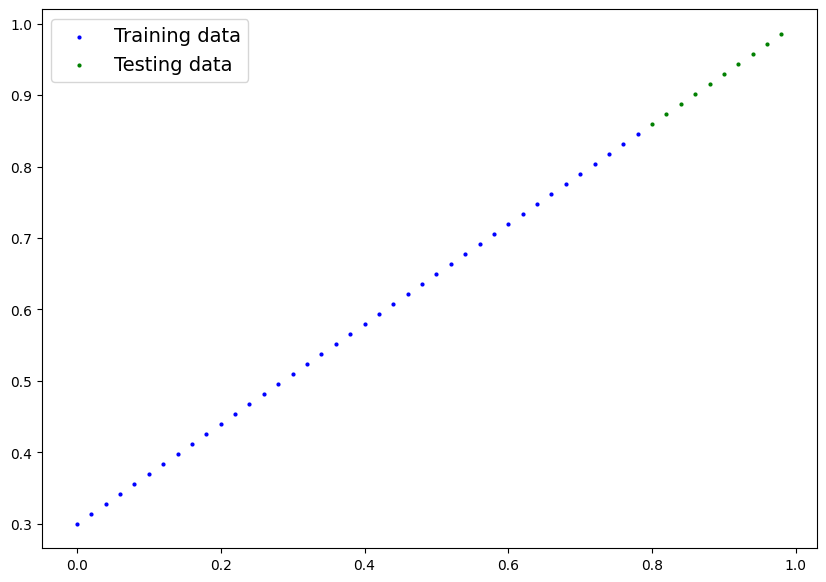

In [13]:
plot_predictions()

In [14]:
class LinearRegressionModel(nn.Module): #(biulding bricks for a pytorch model)
    def __init__(self):
        super().__init__()
        self.weights = nn.Parameter(torch.randn(1, requires_grad=True,
                                                dtype=torch.float))
         
        self.bias = nn.Parameter(torch.randn(1, requires_grad=True, 
                                            dtype = torch.float))
    
    #forward method to define th computation in the model 
    def forward(self, x:torch.Tensor) -> torch.Tensor: 
        return self.weights * x + self.bias #(linear regression formula)
            
        

In [15]:
torch.manual_seed(42)

#Creating an instance of a model we created 


model_0 = LinearRegressionModel()

model_0

LinearRegressionModel()

In [16]:
list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [17]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

In [18]:
with torch.inference_mode():
    y_preds = model_0(X_test)
    
y_preds

tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]])

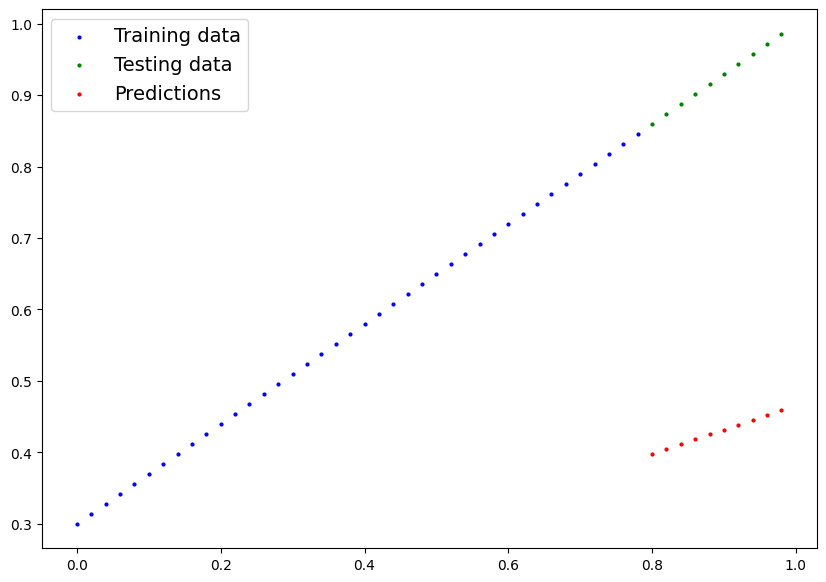

In [19]:
plot_predictions(predictions=y_preds)

In [20]:
#seetting up a loss function
   
loss_fn = nn.L1Loss()


#setting up an optmizer

optimizer = torch.optim.SGD(params=model_0.parameters(),
                            lr=0.01)

In [21]:
optimizer

SGD (
Parameter Group 0
    dampening: 0
    differentiable: False
    foreach: None
    fused: None
    lr: 0.01
    maximize: False
    momentum: 0
    nesterov: False
    weight_decay: 0
)

In [22]:
epochs = 200 #it can be said that one epoch would be a single forward pass to the data

#tracking values
epoch_count = []
loss_values = []
test_loss_values = []


for epoch in range(epochs):
    model_0.train() #sets all parameter that reequires gradients to require bradient 
    
    #1. forward pass
    y_pred = model_0(X_train)
    
    #2. calclulate teh loss 
    loss = loss_fn(y_pred, y_train)
     
    #3. optimzer zero grad
    
    optimizer.zero_grad()
    
    #4. perform backpropagation on the loss with erespect to the parameters of the model
    
    loss.backward() 
    
    #5. step the optimizer (perform gradient descent)
    optimizer.step() #by default how the optimizer changes will acculumate throught the loop,
    # we have to zero them above in step 3 for the next iteration of the loop
    
    
    #Testing
    model_0.eval()
    with torch.inference_mode():
        #doing the forward pass
        test_pred = model_0(X_test)
        
        #calculating the loss
        test_loss = loss_fn(test_pred, y_test)

    if epoch % 10 == 0:
        
        epoch_count.append(epoch)
        loss_values.append(loss)
        test_loss_values.append(test_loss)
        print(f"Epoch: {epoch} | Loss: {loss} | Test Loss: {test_loss}")
        
        print(model_0.state_dict())

Epoch: 0 | Loss: 0.31288138031959534 | Test Loss: 0.48106518387794495
OrderedDict({'weights': tensor([0.3406]), 'bias': tensor([0.1388])})
Epoch: 10 | Loss: 0.1976713240146637 | Test Loss: 0.3463551998138428
OrderedDict({'weights': tensor([0.3796]), 'bias': tensor([0.2388])})
Epoch: 20 | Loss: 0.08908725529909134 | Test Loss: 0.21729660034179688
OrderedDict({'weights': tensor([0.4184]), 'bias': tensor([0.3333])})
Epoch: 30 | Loss: 0.053148526698350906 | Test Loss: 0.14464017748832703
OrderedDict({'weights': tensor([0.4512]), 'bias': tensor([0.3768])})
Epoch: 40 | Loss: 0.04543796554207802 | Test Loss: 0.11360953003168106
OrderedDict({'weights': tensor([0.4748]), 'bias': tensor([0.3868])})
Epoch: 50 | Loss: 0.04167863354086876 | Test Loss: 0.09919948130846024
OrderedDict({'weights': tensor([0.4938]), 'bias': tensor([0.3843])})
Epoch: 60 | Loss: 0.03818932920694351 | Test Loss: 0.08886633068323135
OrderedDict({'weights': tensor([0.5116]), 'bias': tensor([0.3788])})
Epoch: 70 | Loss: 0.03

In [23]:
weight, bias 


(0.7, 0.3)

In [24]:
with torch.inference_mode():
    y_preds_new = model_0(X_test)
    

In [25]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.6990])), ('bias', tensor([0.3093]))])

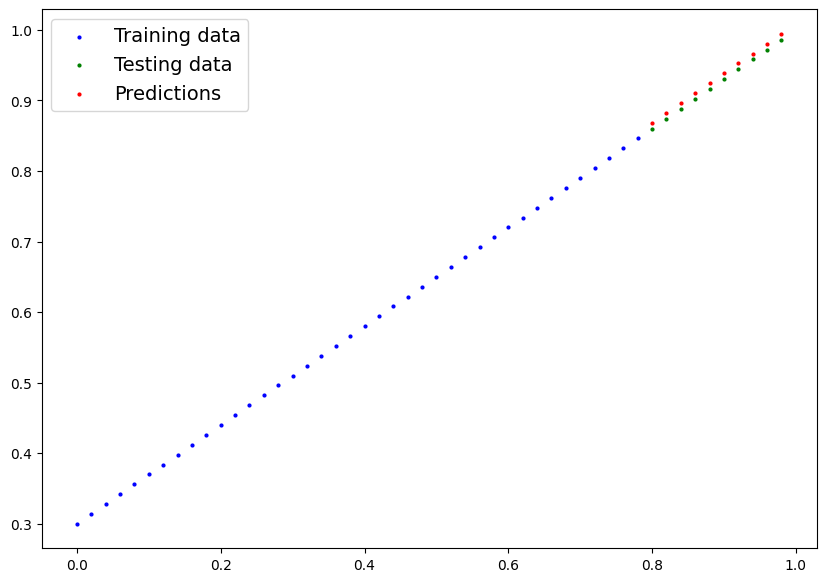

In [26]:
plot_predictions(predictions=y_preds_new)

In [28]:
np.array(torch.tensor(loss_values.numpy()))

AttributeError: 'list' object has no attribute 'numpy'

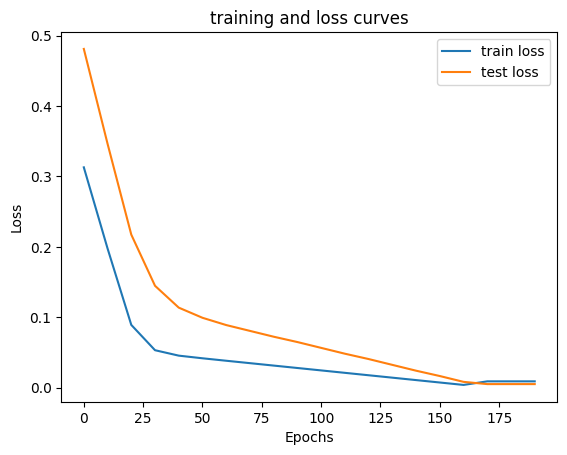

In [29]:
plt.plot(epoch_count, np.array(torch.tensor(loss_values).numpy()), label="train loss")
plt.plot(epoch_count, test_loss_values, label="test loss")

plt.title("training and loss curves")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.legend()

In [30]:
#Creating a model's directory
from pathlib import Path

model_path = Path("models")


model_path.mkdir(parents=True, exist_ok=True)


model_name = "pytorch_workflow_model_0.pth" 

model_save_path = model_path / model_name


#saving model's state dict

torch.save(obj=model_0.state_dict(), f=model_save_path)




In [31]:
#to load in a saved state dict we have to instantiate a new instandce of our new model class


loaded_model_0 = LinearRegressionModel()

#loading the saved state dict of model 0, so it updates new instance with updated parameter

loaded_model_0.load_state_dict(torch.load(f=model_save_path))

C:\Users\soumy\AppData\Local\Temp\ipykernel_29316\2468792247.py:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  loaded_model_0.load_state_dict(torch.load(f=model_save_path)

<All keys matched successfully>

In [32]:
loaded_model_0.state_dict()

OrderedDict([('weights', tensor([0.6990])), ('bias', tensor([0.3093]))])

In [33]:
#making predictions with our loaded model


loaded_model_0.eval()
with torch.inference_mode():
    loaded_model_preds = loaded_model_0(X_test)

In [34]:
y_preds == loaded_model_preds

tensor([[False],
        [False],
        [False],
        [False],
        [False],
        [False],
        [False],
        [False],
        [False],
        [False]])

In [35]:
model_0.eval()
with torch.inference_mode():
    y_preds = model_0(X_test)

In [36]:
y_preds== loaded_model_preds

tensor([[True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True]])

In [37]:
#practice again.

import torch 
from torch import nn 
import matplotlib.pyplot as plt 

torch.__version__


'2.5.1'

In [38]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

cuda


In [39]:
#Creating data again. (for linear regression) y = weight * X + bias 



weight = 0.1
bias = 0.2

#Creating range

start = 0 
end = 1

step = 0.02

#Creating X and y (features and label)

X = torch.arange(start, end, step).unsqueeze(dim=1)
y = weight * X + bias 

X[:10], y [:10]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.2000],
         [0.2020],
         [0.2040],
         [0.2060],
         [0.2080],
         [0.2100],
         [0.2120],
         [0.2140],
         [0.2160],
         [0.2180]]))

In [40]:
#splitting data

train_split = int(0.8 * len(X))

X_train, y_train = X [:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split: ]

len (X_train), len(y_train), len(X_test), len(y_test)

(40, 40, 10, 10)

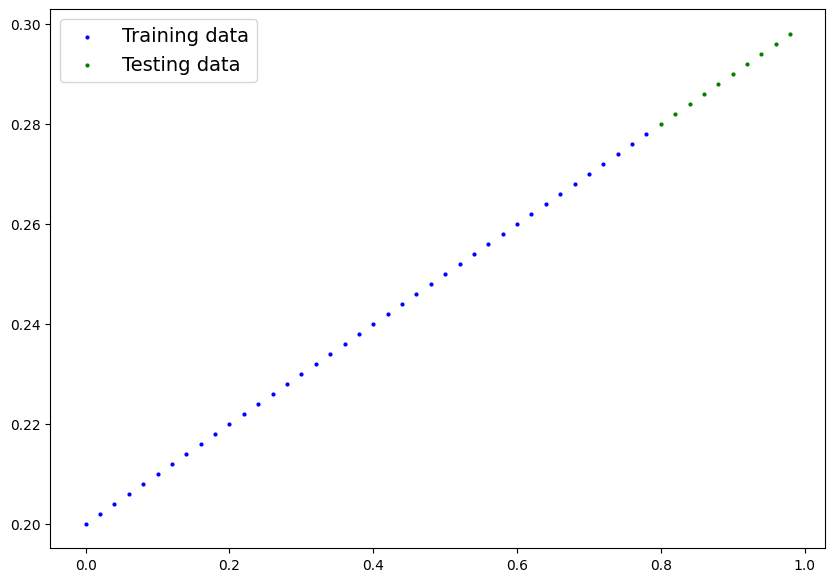

In [41]:
plot_predictions(X_train, y_train, X_test,y_test)

In [42]:
#creating a linewar model by subclassing nn.module 


class LinearRegressionModelV2(nn.Module):
    def __init__(self):
        super().__init__()
        #Using nn.Linear() for creatin the model parameters 
        
        self.linear_layer = nn.Linear(in_features = 1,
                                       out_features = 1)
        
    def forward(self, x : torch.Tensor) -> torch.Tensor:
        return self.linear_layer(x)
#setting the manual seed 

torch.manual_seed(42)
model_1 = LinearRegressionModelV2()
model_1, model_1.state_dict()

(LinearRegressionModelV2(
   (linear_layer): Linear(in_features=1, out_features=1, bias=True)
 ),
 OrderedDict([('linear_layer.weight', tensor([[0.7645]])),
              ('linear_layer.bias', tensor([0.8300]))]))

In [43]:
device 

'cuda'

In [44]:
#checking model's current deivce 

next(model_1.parameters()).device

device(type='cpu')

In [45]:
model_1.to(device)
next(model_1.parameters()).device

device(type='cuda', index=0)

In [46]:
#Training, we need: loss funciton, optmizier, train loop and test loop 

In [47]:
#Setup a loss function 

loss_fun = nn.L1Loss()

#optimizer

optimizer = torch.optim.SGD(params=model_1.parameters(), lr=0.01,)

In [48]:
torch.manual_seed(42)
epochs = 200


#putting data on target device
X_train = X_train.to(device)
y_train = y_train.to(device)
X_test = X_test.to(device)
y_test = y_test.to(device)


for epoch in range(epochs):
    model_1.train()
    
    #forward pass 
    y_pred = model_1(X_train)
    
    #calculate loss
    
    loss = loss_fn(y_pred, y_train)
    
    optimizer.zero_grad()
    
    loss.backward()
    
    optimizer.step()
    
    
    #Testing
    model_1.eval()
    with torch.inference_mode():
        test_pred = model_1(X_test)
        
        test_loss = loss_fn(test_pred, y_test)
        
        
    if epoch %10 == 0:
        print(f"Epoch: {epoch} | Loss: {loss}, | Test loss {test_loss}")

Epoch: 0 | Loss: 0.8891779184341431, | Test loss 1.207976222038269
Epoch: 10 | Loss: 0.7739680409431458, | Test loss 1.0732663869857788
Epoch: 20 | Loss: 0.6587581634521484, | Test loss 0.9385566115379333
Epoch: 30 | Loss: 0.5435482859611511, | Test loss 0.8038467764854431
Epoch: 40 | Loss: 0.4283384382724762, | Test loss 0.6691369414329529
Epoch: 50 | Loss: 0.3131285607814789, | Test loss 0.5344271063804626
Epoch: 60 | Loss: 0.19791868329048157, | Test loss 0.39971718192100525
Epoch: 70 | Loss: 0.10804491490125656, | Test loss 0.28325483202934265
Epoch: 80 | Loss: 0.07703547924757004, | Test loss 0.21338318288326263
Epoch: 90 | Loss: 0.0670076236128807, | Test loss 0.17452800273895264
Epoch: 100 | Loss: 0.062281813472509384, | Test loss 0.15338250994682312
Epoch: 110 | Loss: 0.05861920863389969, | Test loss 0.140328511595726
Epoch: 120 | Loss: 0.05512920767068863, | Test loss 0.12930849194526672
Epoch: 130 | Loss: 0.05166677385568619, | Test loss 0.12034916877746582
Epoch: 140 | Loss:

In [49]:
model_1.state_dict()

OrderedDict([('linear_layer.weight', tensor([[0.2375]], device='cuda:0')),
             ('linear_layer.bias', tensor([0.1425], device='cuda:0'))])

In [50]:
weight, bias

(0.1, 0.2)

In [51]:
model_1.eval()

#making predictions on test datA

with torch.inference_mode():
    y_predss = model_1(X_test)
    
y_predss

tensor([[0.3325],
        [0.3373],
        [0.3420],
        [0.3468],
        [0.3515],
        [0.3563],
        [0.3610],
        [0.3658],
        [0.3705],
        [0.3753]], device='cuda:0')

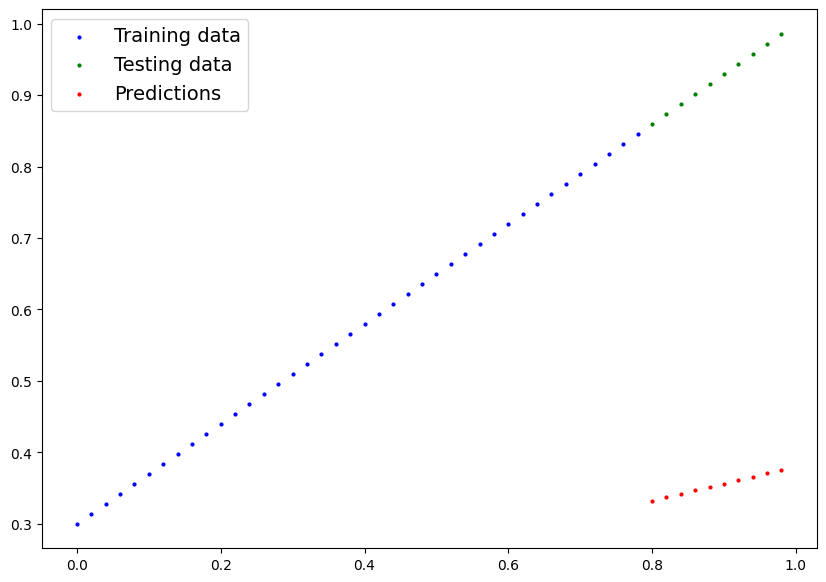

In [57]:
plot_predictions(predictions=y_predss.cpu())